In [1]:
import pandas as pd 
data = pd.read_csv("/home/ego4d/data/v2/video_540ss_splits/test_ego4d.csv")
data.head(1)

,path,num_frames,fps,duration_sec,source
0,/home/ego4d/data/v2/video_540ss_splits/6fd90f8...,5376,30.0,179.2,ego4d


In [2]:
data.iloc[0]['path']

'/home/ego4d/data/v2/video_540ss_splits/6fd90f8d-7a4d-425d-a812-3268db0b0342/6fd90f8d-7a4d-425d-a812-3268db0b0342_0012.mp4'

In [3]:
from models.rvm_tf import RecurrentWorldModel
from sklearn.decomposition import PCA

import torch
import yaml
import numpy as np
import cv2
import math
import matplotlib.pyplot as plt
import torch.nn.functional as F
from icecream import ic
import os

In [ ]:




# dir = '/home/rvm/src/helicop'
# fps = 30
# file_names = [os.path.join(dir, f) for f in os.listdir(dir) if f.endswith("jpg")]
# # file_names
# frames = []
# for f in file_names:
#     frame = cv2.imread(f)
#     frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
#     frame = cv2.resize(frame, (252, 252))
#     frame = frame / 255.0
#     frames.append(frame)

# print(len(frames))
# stride = 5
# frames = frames[::stride]
# print(len(frames))

# # raw frame indices these strided samples correspond to in the original video
# all_indices = np.arange(0, len(frames) * stride, stride)

708
142


In [5]:
with open("/home/rvm/configs/train_ema.yaml", "r") as f:
    config = yaml.safe_load(f)
model = RecurrentWorldModel(**config.get("model", {}))

/root/miniconda3/envs/gssl/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


loading the vision encoder from facebook/dinov2-with-registers-small


Loading weights: 100%|██████████| 224/224 [00:00<00:00, 2131.92it/s]


In [6]:
# checkpoint = torch.load("/home/rvm/checkpoints/checkpoints_rwm/exp_1787891923.9649274/model_epoch3_step5400.pth", weights_only=False)
checkpoint = torch.load("/home/rvm/checkpoints/checkpoints_rwm/full_context/model_epoch1_step3900.pth", weights_only = False)
model.load_state_dict(checkpoint['model'])

<All keys matched successfully>

In [14]:
# # video_path = '/home/ego4d/data/v2/video_540ss/aef6d4d8-7a78-4744-a8a2-dba4edeb1997.mp4'
video_path = data.iloc[807]['path']

fps = cap.get(cv2.CAP_PROP_FPS)  # native fps, used to convert seconds -> frames below

frames = []
while True:
    ret, frame = cap.read()
    if not ret: break
    frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    frame = cv2.resize(frame, (252, 252))
    frame = frame/255.0
    frames.append(frame)    

print(len(frames))
stride_sec = 0.33  # seconds between sampled frames (same convention as rvm_dataset_tf.py)
stride = max(1, round(stride_sec * fps))
sampled_fps = fps / stride  # effective fps of `frames` after subsampling below

frames = frames[int(0.3 * len(frames)):]
frames = frames[::stride]
print(len(frames))

NameError: name 'cap' is not defined

In [15]:


device = "cuda"
model = model.to(device)
model.eval()

# sampled_fps = 30.0 / stride

Base = 15       # starting position in (strided) frames
C = 15           # number of context frames
S = 5            # number of future frames to predict

context_frames = np.stack(frames[Base : Base + C])
context = torch.tensor(context_frames, dtype=torch.float32)                 # (C, H, W, 3)
context = context.permute(0, 3, 1, 2).unsqueeze(0).to(device)               # (1, C, 3, H, W)

target_frames = np.stack(frames[Base + C : Base + C + S])
targets = torch.tensor(target_frames, dtype=torch.float32)                  # (S, H, W, 3)
targets = targets.permute(0, 3, 1, 2).unsqueeze(0).to(device)               # (1, S, 3, H, W)

# `frames` is uniformly spaced at 1/sampled_fps seconds apart (see the loading cell),
# so times/gaps below are real seconds, not frame-index units -- matches
# rvm_dataset_tf.py's frame_times = sampled_indices / fps convention
frame_period = 1.0 / sampled_fps
context_times = (torch.arange(C, dtype=torch.float32) * frame_period).unsqueeze(0).to(device)         # (1, C), seconds
target_times = (torch.arange(C, C + S, dtype=torch.float32) * frame_period).unsqueeze(0).to(device)   # (1, S), seconds

# gaps[i] = target_times[i] - target_times[i-1] (or - context_times[-1] for i=0);
# consecutive sampled frames are frame_period seconds apart, so every gap is frame_period
gaps = torch.full((S,), frame_period, dtype=torch.float32, device=device)   # (S,), seconds

# with torch.no_grad():
#     out = model.rollout(
#         context=context,              # (B, C, 3, H, W)
#         gaps=gaps,                    # (S,) time gaps between predicted steps
#         context_times=context_times,  # (B, C)
#     )

# preds = out["pred"]              # (B, S, n_tok, D) -- repr_head output, one per predicted step
# context_memory = out["context_memory"]   # (B, C+S, n_tok, D) core states, context + rolled-out steps
# # context_state  = out["state"]            # (B, n_tok, D) final GRU state
# context_feats = out['context_feat']

# # recon_tf = out_tf["recon"]      # (B, S, 3, H, W)
# print(preds.shape)

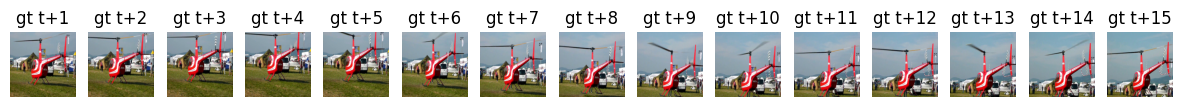

In [16]:
gt = context_frames
fig, axes = plt.subplots(1, C, figsize=(3 * S, 6))
for s in range(C):
    axes[s].imshow(gt[s])
    axes[s].set_title(f"gt t+{s+1}")
    axes[s].axis("off")


In [17]:

with torch.no_grad():
    out_tf = model.teacher_forcing_rollout_repr(
        context=context,
        targets=targets,
        context_times=context_times,
        target_times=target_times,
    )

preds_tf = out_tf["pred"]
target_feat_tf = out_tf["target_feat"]
context_memory_tf = out_tf["context_memory"]
context_feat_tf = out_tf["context_feat"]

# print("context:", context.shape)
# print("targets:", targets.shape)
# print("context_times:", conte xt_times)
# print("target_times:", target_times)
# print("preds_tf:", preds_tf.shape)

loss = F.smooth_l1_loss(preds_tf[:, :, 1:, :], target_feat_tf[:, :, 1:, :], beta = 0.1)
ic(loss)
print("")

ic| loss: tensor(0.5457, device='cuda:0')


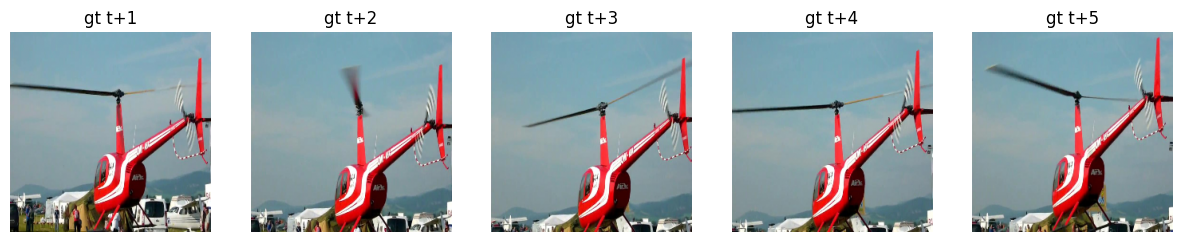

In [18]:
gt = target_frames
fig, axes = plt.subplots(1, S, figsize=(3 * S, 6))
for s in range(S):
    axes[s].imshow(gt[s])
    axes[s].set_title(f"gt t+{s+1}")
    axes[s].axis("off")


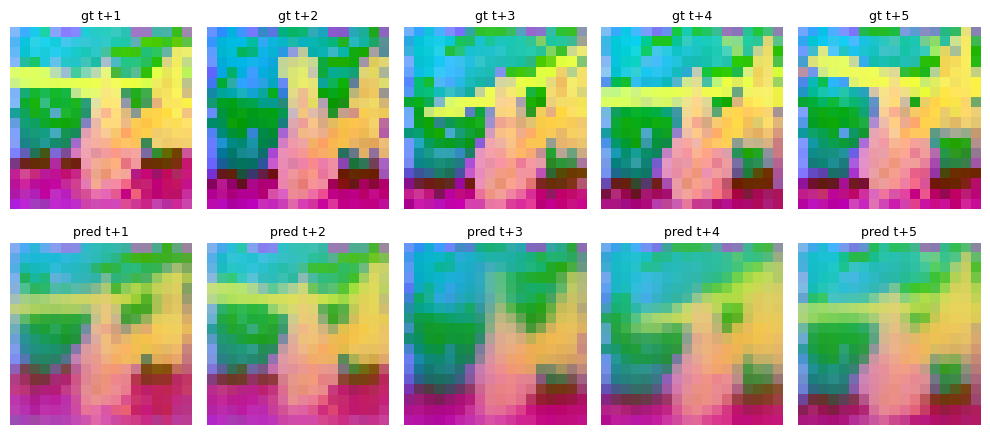

In [19]:

D = 384
gt_patches = target_feat_tf[:, :, 1:, :].reshape(-1, D).cpu()      # all frames pooled
pca = PCA(3).fit(gt_patches)                              # fit ONCE, on GT

gt_rgb   = pca.transform(target_feat_tf[:, :, 1:, :].reshape(-1, D).cpu())
pred_rgb = pca.transform(preds_tf[:, :, 1:, :].reshape(-1, D).cpu())
# normalize both with the SAME min/max, from GT


B, T = target_feat_tf.shape[0], target_feat_tf.shape[1]
P = target_feat_tf.shape[2] - 1
g = int(round(math.sqrt(P)))

# colour range from GT only — percentiles, not min/max: DINOv2 has high-norm
# outlier tokens that would otherwise squash everything into mid-grey
lo = np.percentile(gt_rgb, 2, axis=0)
hi = np.percentile(gt_rgb, 98, axis=0)
span = np.where(hi - lo < 1e-8, 1.0, hi - lo)

gt_img   = np.clip((gt_rgb   - lo) / span, 0, 1).reshape(B, T, g, g, 3)
pred_img = np.clip((pred_rgb - lo) / span, 0, 1).reshape(B, T, g, g, 3)

b = 0
fig, ax = plt.subplots(2, T, figsize=(2 * T, 4.6))
ax = np.atleast_2d(ax)
for t in range(T):
    ax[0, t].imshow(gt_img[b, t], interpolation="nearest")
    ax[0, t].set_title(f"gt t+{t+1}", fontsize=9)
    ax[1, t].imshow(pred_img[b, t], interpolation="nearest")
    ax[1, t].set_title(f"pred t+{t+1}", fontsize=9)
    ax[0, t].axis("off"); ax[1, t].axis("off")
plt.tight_layout()
plt.show()

frame 0: explained variance = [0.347 0.151 0.08 ]  (sum 0.578)
frame 1: explained variance = [0.352 0.176 0.07 ]  (sum 0.598)
frame 2: explained variance = [0.439 0.136 0.082]  (sum 0.657)
frame 3: explained variance = [0.408 0.148 0.077]  (sum 0.632)
frame 4: explained variance = [0.37  0.165 0.085]  (sum 0.620)


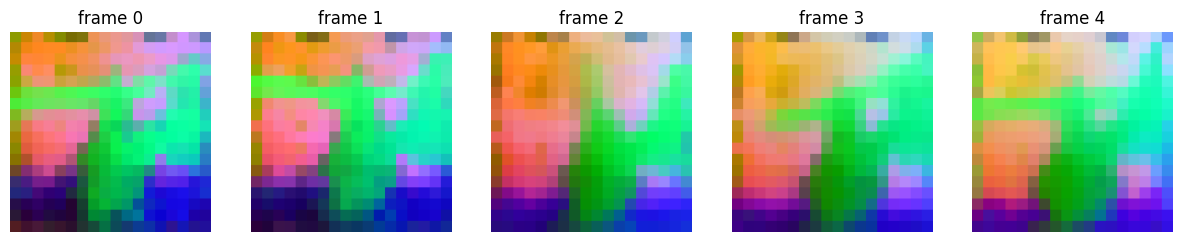

In [20]:
from pca_vis import pca_per_frame, show
# preds.shape
pca_feats = pca_per_frame(preds_tf[:, :, 1:, :])
feats_pca_image = show(pca_feats)

frame 0: explained variance = [0.292 0.164 0.063]  (sum 0.519)
frame 1: explained variance = [0.342 0.118 0.067]  (sum 0.527)
frame 2: explained variance = [0.332 0.117 0.071]  (sum 0.519)
frame 3: explained variance = [0.322 0.129 0.065]  (sum 0.516)
frame 4: explained variance = [0.32  0.127 0.067]  (sum 0.515)


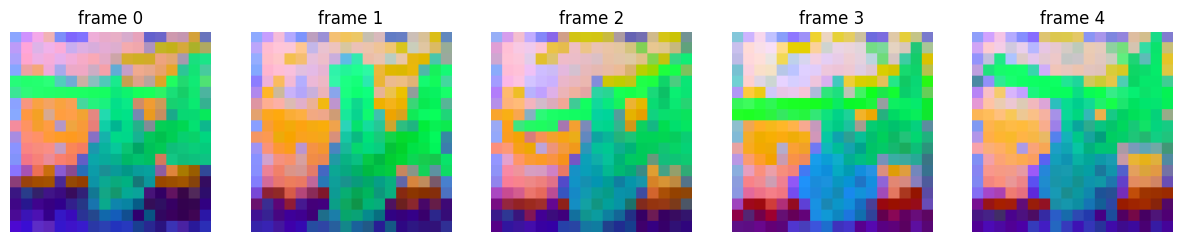

In [13]:
from pca_vis import pca_per_frame, show
# preds.shape
pca_feats = pca_per_frame(target_feat_tf[:, :, 1:, :])
feats_pca_image = show(pca_feats)

In [ ]:


def frame_knn(ground_truth_feat, predicted_feat, indices, topk=(1, 3, 5), context_len=None):
    bs, T_gt, num_p, dim = ground_truth_feat.shape
    T_pred = predicted_feat.shape[1]
    device = predicted_feat.device

    gt = F.normalize(ground_truth_feat[:, :, 1:], dim=-1)
    pred = F.normalize(predicted_feat[:, :, 1:], dim=-1)
    sim = torch.einsum("btpd,bspd->bts", pred, gt) / gt.shape[2]

    order = sim.argsort(dim=-1, descending=True)
    idx = torch.as_tensor(indices, device=device).view(1, T_pred, 1)
    rank = (order == idx).float().argmax(dim=-1)

    gt_sim = sim.gather(-1, idx.expand(bs, T_pred, 1)).squeeze(-1)
    best_sim = sim.gather(-1, order[..., :1]).squeeze(-1)

    out = {f"top{k}": (rank < k).float().mean().item() for k in topk}
    out["mean_rank"] = rank.float().mean().item()
    out["per_step_rank"] = rank.float().mean(0).tolist()
    out["chance_top1"] = 1.0 / T_gt

    out["sim"] = sim                                  # (B, T_pred, T_gt) full matrix
    out["retrieved"] = order[..., 0]                  # (B, T_pred) best-matching gt index
    out["target"] = idx.expand(bs, T_pred, 1).squeeze(-1)
    out["retrieved_sim"] = best_sim                   # score of the retrieved frame
    out["target_sim"] = gt_sim                        # score of the frame it should have been
    out["rank"] = rank                                # (B, T_pred) per-sample rank
    out["order"] = order                              # (B, T_pred, T_gt) full ranking

    if context_len is not None:
        last = context_len - 1
        out["copy_rate"] = (order[..., 0] == last).float().mean().item()
        out["copy_sim"] = sim[..., last]
        out["copy_beats_gt"] = (sim[..., last] > gt_sim).float().mean().item()

    return out

representations = torch.cat((context_feat_tf, target_feat_tf), dim=1)

C = context_feat_tf.shape[1]
S = target_feat_tf.shape[1]
indices = list(range(C, C + S))
print(C, S)
r = frame_knn(representations, preds_tf, indices, context_len=C)
for s in range(len(indices)):
    print(f"s={s}  want {r['target'][0,s].item():2d} (sim {r['target_sim'][0,s]:.4f})   "
          f"got {r['retrieved'][0,s].item():2d} (sim {r['retrieved_sim'][0,s]:.4f})   "
          f"copy {r['copy_sim'][0,s]:.4f}   rank {int(r['rank'][0,s])}")

In [87]:
print(preds_tf.shape)            # is it S, or C+S, or C+S-1?
# print(out_full.shape)            # whatever preds_tf was sliced from
# and confirm the shift hypothesis directly:
r2 = frame_knn(representations, preds_tf, [i-1 for i in indices], context_len=C)
print(r2["top1"], r2["target_sim"][0])   # ~1.0 and ~0.97 => pure alignment bug

torch.Size([1, 5, 325, 384])
1.0 tensor([0.9699, 0.9736, 0.9305, 0.9456, 0.9471], device='cuda:0')


frame 0: explained variance = [0.282 0.123 0.097]  (sum 0.502)
frame 1: explained variance = [0.239 0.154 0.081]  (sum 0.474)
frame 2: explained variance = [0.203 0.153 0.11 ]  (sum 0.466)
frame 3: explained variance = [0.288 0.141 0.082]  (sum 0.511)
frame 4: explained variance = [0.318 0.128 0.075]  (sum 0.522)
frame 5: explained variance = [0.351 0.092 0.084]  (sum 0.527)
frame 6: explained variance = [0.36  0.092 0.079]  (sum 0.532)


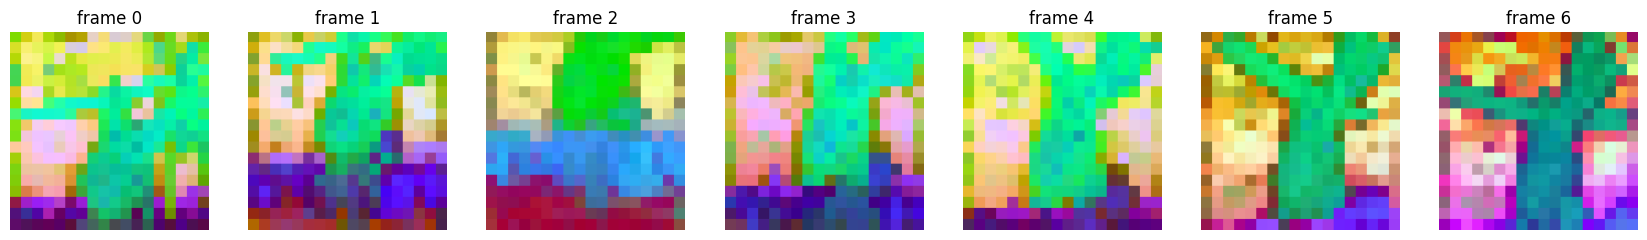

In [16]:
pca_feats = pca_per_frame(context_memory_tf[:, C-7:C, 1:, :])
feats_pca_image = show(pca_feats)


frame 0: explained variance = [0.307 0.123 0.082]  (sum 0.512)
frame 1: explained variance = [0.257 0.165 0.07 ]  (sum 0.492)
frame 2: explained variance = [0.224 0.175 0.107]  (sum 0.505)
frame 3: explained variance = [0.313 0.142 0.062]  (sum 0.517)
frame 4: explained variance = [0.342 0.127 0.064]  (sum 0.533)
frame 5: explained variance = [0.374 0.097 0.076]  (sum 0.547)
frame 6: explained variance = [0.38  0.092 0.072]  (sum 0.544)


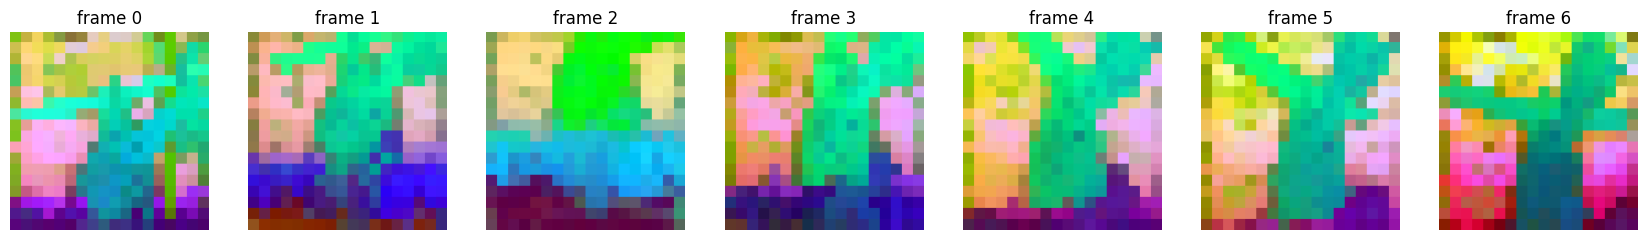

In [17]:
pca_feats = pca_per_frame(context_feat_tf[:, C-7:C, 1:, :])
feats_pca_image = show(pca_feats)

frame 0: explained variance = [0.318 0.128 0.075]  (sum 0.522)
frame 1: explained variance = [0.351 0.092 0.084]  (sum 0.527)
frame 2: explained variance = [0.36  0.092 0.079]  (sum 0.532)
frame 0: explained variance = [0.342 0.127 0.064]  (sum 0.533)
frame 1: explained variance = [0.374 0.097 0.076]  (sum 0.547)
frame 2: explained variance = [0.38  0.092 0.072]  (sum 0.544)


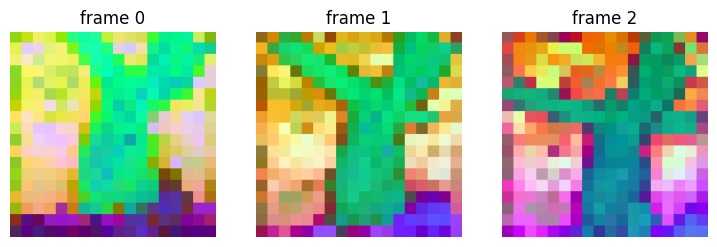

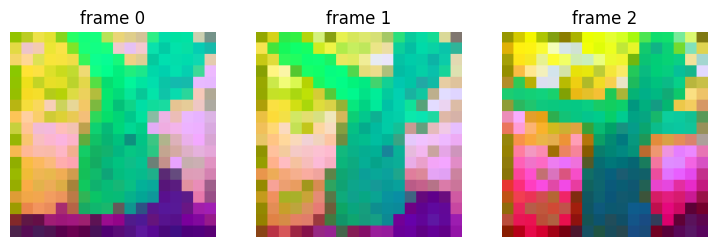

In [18]:
from pca_vis import pca_per_frame, show
# preds.shape
pca_feats = pca_per_frame(context_memory_tf[:, C-3:C, 1:, :])
feats_pca_image = show(pca_feats)

pca_memory = pca_per_frame(context_feat_tf[:, C-3:C, 1:, :])
memory_pca_image = show(pca_memory)

frame 0: explained variance = [0.21  0.165 0.112]  (sum 0.487)
frame 1: explained variance = [0.235 0.144 0.103]  (sum 0.482)
frame 2: explained variance = [0.243 0.13  0.096]  (sum 0.468)
frame 3: explained variance = [0.224 0.147 0.106]  (sum 0.477)
frame 4: explained variance = [0.262 0.154 0.065]  (sum 0.481)
frame 5: explained variance = [0.282 0.136 0.063]  (sum 0.480)
frame 6: explained variance = [0.293 0.145 0.064]  (sum 0.503)
frame 7: explained variance = [0.331 0.126 0.068]  (sum 0.525)
frame 8: explained variance = [0.307 0.123 0.082]  (sum 0.512)
frame 9: explained variance = [0.257 0.165 0.07 ]  (sum 0.492)
frame 10: explained variance = [0.224 0.175 0.107]  (sum 0.505)
frame 11: explained variance = [0.313 0.142 0.062]  (sum 0.517)
frame 12: explained variance = [0.342 0.127 0.064]  (sum 0.533)
frame 13: explained variance = [0.374 0.097 0.076]  (sum 0.547)
frame 14: explained variance = [0.38  0.092 0.072]  (sum 0.544)


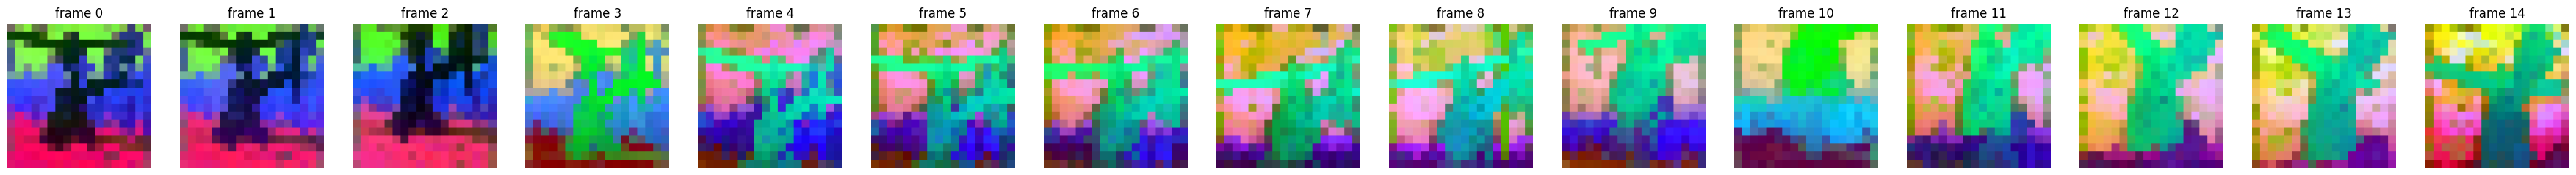

In [19]:
from pca_vis import pca_per_frame, show
# preds.shape
pca_memory = pca_per_frame(context_feat_tf[:, :C, 1:, :])
memory_pca_image = show(pca_memory)